In [45]:
from __future__ import annotations

import yaml
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from plotting_globals import GAS_COLOR

idx = pd.IndexSlice

In [46]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

# inplace update: give these gas-ish techs a more diverse palette (not all brown)
tech_colors.update({
    "SMR CC":                        "#1f77b4",  # blue
    "heat100-200 industry gas":      "#ff7f0e",  # orange
    "heat<100 industry gas":         "#2ca02c",  # green
    "Combined-Cycle Gas":            "#d62728",  # red
    "Open-Cycle Gas":                "#9467bd",  # purple
    "heat200-500 industry gas":      "#17becf",  # cyan
    "H2 electrolysis":               "#e377c2",  # pink
    "urban central gas boiler":      "#7f7f7f",  # grey
    "urban central gas CHP":         "#bcbd22",  # olive
    "rural gas boiler":              "#8c564b",  # brown (keep one brown, but not all)
    "urban decentral gas boiler":    "#aec7e8",  # light blue
    "urban decentral biomass boiler":"#92648c",  # purple
    "rural biomass boiler":          "#94312c",  # purple
    "heat>500 industry gas":         "#98df8a",  # light green
    "gas DRI":                       "#000000",  # black
    "hydrogen heating":               "magenta",

    # ">500C industry heat and feedstock": "#17becf",
    # "<500C industry heat":               "#98df8a",
    # "biomethane":                        "gold",
    # "building heat":                  "#94312c",
    # "electricity":                  "#d62728",
    # "hydrogen":                     "#bf13a0", 
    ">500C industry heat and feedstock": "#4A9BA8",
    "<500C industry heat": "#6BBF8A",
    "biomethane": "#E8C547",
    "building heat": "#C2714F",
    "electricity": "#D94F5C",
    "hydrogen": "#8B6BBF",
})

tech_colors['AC'] = tech_colors['electricity']
tech_colors['residential heating'] = tech_colors['building heat']
tech_colors['low-temperature industry heat'] = tech_colors['<500C industry heat']

tech_colors['residential gas boiler'] = tech_colors['urban decentral gas boiler']
tech_colors['gas turbine'] = tech_colors['Open-Cycle Gas']
tech_colors['wind'] = tech_colors['Onshore Wind']
tech_colors['solar'] = tech_colors['solar-hsat']
tech_colors['biomass buildings'] = tech_colors['urban decentral biomass boiler']
tech_colors['biomass industry'] = tech_colors['heat200-500 industry solid biomass']
tech_colors['building heat pump'] = tech_colors['ground heat pump']
tech_colors['rural ground heat pump'] = tech_colors['ground heat pump']
tech_colors['rural oil boiler'] = tech_colors['oil boiler']
tech_colors['urban decentral oil boiler'] = tech_colors['oil boiler']
tech_colors['urban decentral air heat pump'] = tech_colors['air heat pump']
tech_colors['urban decentral resistive heater'] = tech_colors['resistive heater']
tech_colors['rural resistive heater'] = tech_colors['resistive heater']
tech_colors['building electric heating'] = tech_colors['ground heat pump']
tech_colors['industrial heat pump'] = tech_colors['heat<100 industry industrial heat pump medium temperature']


In [47]:
tech_colors['hydrogen']

'#8B6BBF'

In [48]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [ ]:
mode = '3' # -hourly resolution

nb = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'nodal_energy_balance.csv', index_col=list(range(4)), header=list(range(5))
).loc[:,idx[:,:,:,'free']]
nb.columns = nb.columns.get_level_values(-1).astype(int)

In [50]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
bal.columns = bal.columns.get_level_values(-1).astype(int)

In [51]:
mp = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
mp.columns = mp.columns.get_level_values(-1).astype(int)

commodity_prices = mp.loc[['gas', 'low voltage', 'urban decentral heat', 'heat<100 industry', 'solid biomass']]
# gas_price.index = gas_price.index.get_level_values(-1)
commodity_prices.head()

commidity_nice_names = {
    'gas': 'gas',
    'low voltage': 'electricity',
    'urban decentral heat': 'residential heating',
    'heat<100 industry': 'low-temperature\nindustry heat',
    'solid biomass': 'biomass',
}
commidity_colors = {
    'gas': tech_colors['gas'],
    'low voltage': tech_colors['AC'],
    'urban decentral heat': tech_colors['urban decentral gas boiler'],
    'heat<100 industry': tech_colors['heat<100 industry'],
    'solid biomass': tech_colors['solid biomass'],
}

In [52]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(gascon.columns[-1])

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [53]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = mp.columns[-1] # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

ignored = [
    'gas for industry CC',
    'gas for industry',
    ]

df.drop(ignored, inplace=True)

df['gas_consumption'] = gasuse_baseline - df['phase_out_volume']
xlim_lower = 1000
xlim_upper = 4000

##### energy balances

In [54]:
eb = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
eb.columns = eb.columns.get_level_values(-1).astype(int)
prices = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'prices.csv', header=list(range(5)), index_col=[0]
)
prices.columns = prices.columns.get_level_values(-1).astype(int)

In [55]:
gas_techs_by_bus = {
    "heat<100 industry": ["heat<100 industry gas"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas", "urban central gas CHP"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
    "Hydrogen Storage": ["SMR"],
    "heat>500 industry": ["heat>500 industry gas"],
}

nice_demand_names = {
    "heat<100 industry": "Industry Heat <100°C",
    "heat100-200 industry": "Industry Heat 100-200°C",
    "heat200-500 industry": "Industry Heat 200-500°C",
    "AC": "Electricity",
    "rural heat": "Rural Heating",
    "urban central heat": "District Heating",
    "urban decentral heat": "Urban Decentral Heating",
    "Hydrogen Storage": "Hydrogen",
    "heat>500 industry": "Industry Heat >500°C",
}

In [56]:
costs = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'costs.csv', index_col=list(range(3)), header=list(range(5))
).sum().mul(1e-9)
costs.index = costs.index.get_level_values(-1)
# Interpolate value for 1750 instead of dropping it
if '1750' in costs.index:
    i = costs.index.get_loc('1750')
    if i > 0 and i < len(costs) - 1:
        prev_val = costs.iloc[i - 1]
        next_val = costs.iloc[i + 1]
        costs.iloc[i] = (prev_val + next_val) / 2
costs.name = 'System Cost [B€]'
costs.index.name = 'Gas Consumption [TWh/a]'

In [57]:
items = [
    # "heat>500 industry gas CC",
    "gas for industry",
    "heat>500 industry gas",
    "heat200-500 industry gas",
    # "gas for industry CC",
    # "Open-Cycle Gas",
    # "Combined-Cycle Gas",
    "gas turbine",
    "residential gas boiler",
    "urban central gas CHP",
    # "SMR CC",
    "SMR",
    "heat<100 industry gas",
    "heat100-200 industry gas",
    "biogas to gas",
]

In [58]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

In [59]:
carrier_mapping = {
    'gas for industry': '>500C industry heat and feedstock',
    'heat>500 industry gas': '>500C industry heat and feedstock',
    'heat200-500 industry gas': '<500C industry heat',
    'heat100-200 industry gas': '<500C industry heat',
    'heat<100 industry gas': '<500C industry heat',
    'biogas to gas': 'biomethane',
    'SMR': 'hydrogen',
    'urban decentral gas boiler': 'building heat',
    'urban central gas boiler': 'building heat',
    'urban central gas CHP': 'building heat',
    'rural gas boiler': 'building heat',
    'Open-Cycle Gas': 'electricity',
    'Combined-Cycle Gas': 'electricity',
}

color_mapper = {
    'heat<100 industry': '<500C industry heat',
    'heat100-200 industry': '<500C industry heat',
    'heat200-500 industry': '<500C industry heat',
    'heat>500 industry': '>500C industry heat and feedstock',
    'AC': 'electricity',
    'rural heat': 'building heat',
    'urban central heat': 'building heat',
    'urban decentral heat': 'building heat',
    'Hydrogen Storage': 'hydrogen',
}

items = [
    '>500C industry heat and feedstock',
    'electricity',
    'hydrogen',
    '<500C industry heat',
    'building heat',
    'biomethane',
]
nice_names = {
    'heat<100 industry industrial heat pump medium temperature': 'heat pump',
    'heat<100 industry solid biomass': 'biomass',
    'heat<100 industry gas': 'gas boiler',
    'heat100-200 industry industrial heat pump high temperature': 'heat pump',
    'heat100-200 industry solid biomass': 'biomass',
    'heat100-200 industry gas': 'gas boiler',
    'heat200-500 industry solid biomass': 'biomass',
    'heat200-500 industry gas': 'direct firing gas',
    'Offshore Wind (AC)': 'Offshore Wind (AC)',
    'Offshore Wind (DC)': 'Offshore Wind (DC)',
    'Onshore Wind': 'Onshore Wind',
    'Run of River': 'Run-of-River',
    'Solar': 'Solar PV',
    'coal': 'Coal',
    'lignite': 'Lignite',
    'urban central solid biomass CHP': 'Central biomass CHP',
    'Reservoir & Dam': 'Hydro (res+dam)',
    'Combined-Cycle Gas': 'CCGT',
    'urban central gas CHP': 'CHP',
    'rural biomass boiler': 'biomass boiler',
    'rural ground heat pump': 'ground heat pump',
    'rural oil boiler': 'oil boiler',
    'rural resistive heater': 'resistive heater',
    'rural gas boiler': 'gas boiler',
    'H2 Electrolysis': 'Electrolysis',
    'Haber-Bosch': 'Haber-Bosch',
    'urban central air heat pump': 'air heat pump',
    'urban central resistive heater': 'resistive heater',
    'urban central solid biomass CHP': 'biomass CHP',
    'urban central gas CHP': 'CHP',
    'urban central gas boiler': 'gas boiler',
    'urban decentral air heat pump': 'air heat pump',
    'urban decentral biomass boiler': 'biomass boiler',
    'urban decentral oil boiler': 'oil boiler',
    'urban decentral resistive heater': 'resistive heater',
    'urban decentral gas boiler': 'gas boiler',
    'H2 Electrolysis': 'Electrolysis',
    'SMR': 'steam-methane reforming',
    'heat>500 industry hydrogen': 'hydrogen',
    'heat>500 industry gas': 'direct firing gas',
}



/tmp/ipykernel_4981/3117833890.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


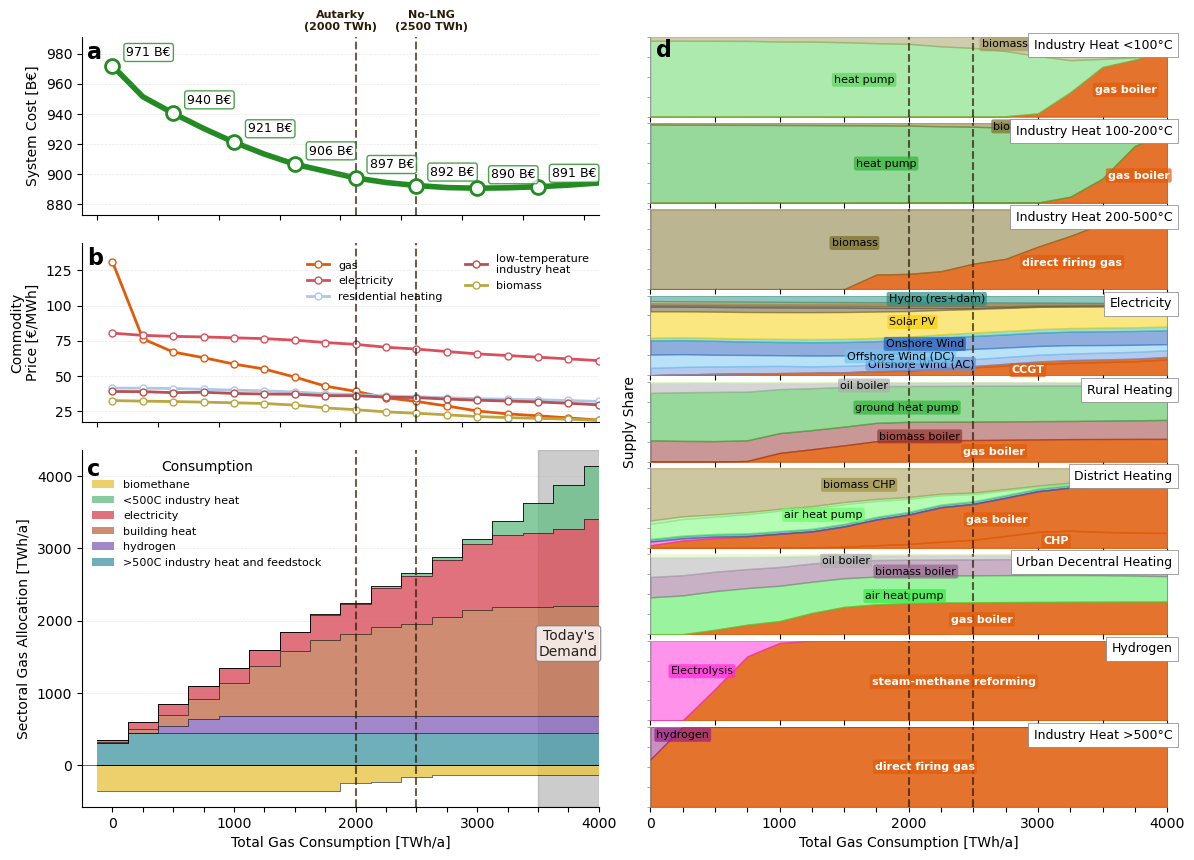

In [60]:
consumption_threshold_color = '#2B1B07'  # a darker brown color

# ============================================================
# DATA PREPARATION
# ============================================================

# --- Left column data ---

gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

# System cost vs gas consumption
cost_x = np.arange(len(costs)) + 0.5
cost_values = costs.values
cost_y_min = costs.min() * 0.98
cost_y_max = costs.max() * 1.02

# Commodity prices vs gas consumption
commodity_x = np.arange(len(commodity_prices.columns)) + 0.5
commodity_y_min = commodity_prices.min().min() * 0.95
commodity_y_max = commodity_prices.max().max() * 1.1

# Sectoral gas allocation (stacked bar data)
gb = gb.groupby(carrier_mapping).sum()

sector_items = [
    '>500C industry heat and feedstock',
    'hydrogen',
    'building heat',
    'electricity',
    '<500C industry heat',
    'biomethane',
]

# Pre-compute bar positions and heights
bar_data = []  # list of (carrier, col_index, value, bottom, color)
bottoms_pos = pd.Series(0, index=gb.columns, dtype=float)
bottoms_neg = pd.Series(0, index=gb.columns, dtype=float)

for carrier in sector_items:
    row = gb.loc[carrier]
    for j, con in enumerate(row.index):
        value = row.loc[con] * (-1)
        if value < 0:
            bar_data.append((carrier, j, value, bottoms_neg.loc[con], tech_colors[carrier]))
            bottoms_neg.loc[con] += value
        else:
            bar_data.append((carrier, j, value, bottoms_pos.loc[con], tech_colors[carrier]))
            bottoms_pos.loc[con] += value

# Step line envelopes per carrier layer
envelope_data = []
running_pos = pd.Series(0, index=gb.columns, dtype=float)
running_neg = pd.Series(0, index=gb.columns, dtype=float)
for carrier in sector_items:
    row = gb.loc[carrier]
    for j, con in enumerate(row.index):
        value = row.loc[con] * (-1)
        if value < 0:
            running_neg.loc[con] += value
        else:
            running_pos.loc[con] += value
    envelope_data.append((
        np.arange(len(running_pos) + 1),
        np.append(running_pos.values, running_pos.values[-1]),
        np.append(running_neg.values, running_neg.values[-1]),
    ))

sector_xlim = (-0.5, len(bottoms_pos) - 0.5)
sector_xticks = np.arange(len(bottoms_pos)) + 0.5
sector_xticklabels = [label if i % 4 == 0 else '' for i, label in enumerate(bottoms_pos.index)]

# --- Right column data: full technology share per bus carrier ---

idx = pd.IndexSlice
gas_prices = prices.loc['gas']

price_thresholds = [20, 30, 50, 100]
x_at_price = {}
for pt in price_thresholds:
    x_at_price[pt] = np.interp(pt, gas_prices.values[::-1], gas_prices.index[::-1])

# For each bus carrier, compute share of demand met by each technology
right_panel_data = {}  # {bus_carrier: DataFrame with tech shares}

for bc, gas_techs in gas_techs_by_bus.items():
    ss = eb.loc[idx[:, :, bc], :]
    
    # Total inflow per column (sum of positive values)
    total_inflow = ss[ss > 0].sum(axis=0)
    
    # Get all technologies contributing to this bus
    all_techs = ss.index.get_level_values(1).unique()
    
    tech_shares = {}
    for tech in all_techs:
        try:
            contrib = ss.loc[idx[:, tech, :], :].sum(axis=0)
        except KeyError:
            continue
        share = (contrib / total_inflow * 100).fillna(0)
        # Only keep techs with positive contribution somewhere
        if (share > 0.5).any():
            tech_shares[tech] = share
    
    shares_df = pd.DataFrame(tech_shares, index=prices.columns)
    
    # Separate gas techs from non-gas techs
    gas_tech_names = [t for t in gas_techs if t in shares_df.columns]
    non_gas_tech_names = [t for t in shares_df.columns if t not in gas_techs]
    
    # Order: gas techs first (bottom), then non-gas techs
    ordered_cols = gas_tech_names + non_gas_tech_names
    shares_df = shares_df[[c for c in ordered_cols if c in shares_df.columns]]
    
    # Normalize so each column sums to ~100 (in case of rounding)
    row_sums = shares_df.sum(axis=1)
    shares_df = shares_df.div(row_sums, axis=0) * 100
    shares_df = shares_df.fillna(0)
    
    right_panel_data[bc] = {
        'shares': shares_df,
        'gas_techs': gas_tech_names,
        'non_gas_techs': non_gas_tech_names,
    }

right_panel_data['AC']['shares']['Solar'] += right_panel_data['AC']['shares']['solar-hsat']
right_panel_data['AC']['shares'].drop(columns=['solar-hsat'], inplace=True)

# ============================================================
# PLOTTING
# ============================================================

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8,
}

width = 1
n_right = len(gas_techs_by_bus)

fig = plt.figure(figsize=(14, 10))
outer = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.1,
)

# Left column: 3 axes stacked
gs_left = outer[0, 0].subgridspec(3, 1, height_ratios=[1.5, 1.5, 3], hspace=0.12)
ax_cost = fig.add_subplot(gs_left[0])
ax_comm = fig.add_subplot(gs_left[1])
ax_alloc = fig.add_subplot(gs_left[2])

# Right column: n_right axes
gs_right = outer[0, 1].subgridspec(n_right, 1, hspace=0.08)
ax_right = [fig.add_subplot(gs_right[i]) for i in range(n_right)]

# --- Left: System Cost ---
cost_color = 'forestgreen'
ax_cost.plot(cost_x, cost_values, color=cost_color, linewidth=4, zorder=0)
ax_cost.set_ylim(cost_y_min, cost_y_max)
ax_cost.set_ylabel('System Cost [B€]')

for i in range(0, len(cost_x) - 2, 2):
    ax_cost.annotate(
        f"{int(cost_values[i])} B€",
        xy=(cost_x[i], cost_values[i]),
        xytext=(10, 5),
        textcoords="offset points",
        ha='left', va='bottom',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cost_color, lw=1, alpha=0.8),
        zorder=20,
    )
    ax_cost.plot(cost_x[i], cost_values[i], marker='o', color=cost_color,
                 markersize=10, markerfacecolor='white',
                 markeredgecolor=cost_color, markeredgewidth=2, zorder=15)

# Place label "a" at upper left of ax_cost
ax_cost.text(0.01, 0.98, "a", transform=ax_cost.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")

# --- Left: Commodity Prices ---
comm_handles = []
comm_labels = []
for name, row in commodity_prices.iterrows():
    x = np.arange(len(row)) + width / 2
    line, = ax_comm.plot(
        x, row.values,
        color=commidity_colors[name],
        linewidth=2, zorder=0,
        marker='o', markersize=5,
        markerfacecolor='white',
        markeredgecolor=commidity_colors[name],
        markeredgewidth=1,
    )
    comm_handles.append(line)
    comm_labels.append(commidity_nice_names[name])

ax_comm.set_ylim(commodity_y_min, commodity_y_max)
ax_comm.set_ylabel('Commodity\nPrice [€/MWh]')
ax_comm.legend(comm_handles, comm_labels, loc='upper right', frameon=False, ncol=2, fontsize=8)

# Place label "b" at upper left of ax_comm
ax_comm.text(0.01, 0.98, "b", transform=ax_comm.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")

# --- Left: Sectoral Gas Allocation ---
ax_alloc.axhline(0, **line_kwargs)

for carrier, col_idx, value, bottom, color in bar_data:
    ax_alloc.bar(col_idx + width / 2, value, bottom=bottom, color=color, alpha=0.8, width=1)

for step_x, env_pos, env_neg in envelope_data:
    ax_alloc.step(step_x, env_pos, where='post', **line_kwargs)
    ax_alloc.step(step_x, env_neg, where='post', **line_kwargs)

ax_alloc.set_xlim(*sector_xlim)
ax_alloc.set_xticks(sector_xticks)
ax_alloc.set_xticklabels(sector_xticklabels, rotation=0)
ax_alloc.set_ylabel('Sectoral Gas Allocation [TWh/a]')

handles = []
labels = []
for carrier in sector_items[::-1]:
    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)
ax_alloc.legend(handles, labels, loc='upper left', frameon=False, ncol=1, title='Consumption', fontsize=8)

# Place label "c" at upper left of ax_alloc
ax_alloc.text(0.01, 0.98, "c", transform=ax_alloc.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")

# Shared formatting for left column
for ax in [ax_cost, ax_comm, ax_alloc]:
    ax.set_xlim(*sector_xlim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3, linewidth=0.5, axis='y')
    ax.set_axisbelow(True)

# Remove x labels from top two left axes
ax_cost.set_xticklabels([])
ax_comm.set_xticklabels([])
ax_alloc.set_xlabel('Total Gas Consumption [TWh/a]')

# Overlay a low alpha grey region for "Today's Demand" on ax_alloc between 13.5 and 16.5
ymin, ymax = ax_alloc.get_ylim()
ax_alloc.axvspan(14.5, 16.5, ymin=0, ymax=1, color='grey', alpha=0.4, zorder=-1)
ax_alloc.text(
    15.5,
    ymax - 0.5*(ymax-ymin),
    "Today's\nDemand",
    color='black',
    fontsize=10,
    ha='center',
    va='top',
    alpha=0.85,
    zorder=5,
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='grey', alpha=0.8)
)

# --- Right column: Full stacked area per bus carrier ---
middle_ax_index = n_right // 2

for i, (bc, panel) in enumerate(right_panel_data.items()):
    ax = ax_right[i]
    shares = panel['shares']
    gas_techs = panel['gas_techs']
    non_gas_techs = panel['non_gas_techs']
    x_values = shares.index.values

    # Build stacked arrays
    cumulative = np.zeros(len(x_values))
    
    # Plot gas techs first (bottom)
    import numpy as np
    import matplotlib.colors as mcolors

    def compute_area_com(y_values, x_values, base_bottom):
        """
        Compute the area-weighted center of mass of the filled area for a stack segment.

        Args:
            y_values: np.ndarray, the values for this tech's stacked segment
            x_values: np.ndarray, the x locations (same length as y_values)
            base_bottom: np.ndarray, the cumulative bottom (same length as y_values)
        Returns:
            (x_com, y_com): tuple of floats - center of mass in data coordinates
        """
        # The area thickness at each x: h = y_values, x span between points: dx
        dxs = np.diff(x_values, prepend=x_values[0])
        segment_areas = y_values * dxs
        total_area = segment_areas.sum()
        if total_area == 0:
            return x_values[len(x_values)//2], base_bottom[len(x_values)//2] + y_values[len(x_values)//2] / 2
        # x c.o.m.: area weighted
        x_com = np.sum(x_values * segment_areas) / total_area
        # y c.o.m.: average of bottoms + half of y, weighted by area
        y_centers = base_bottom + y_values / 2
        y_com = np.sum(y_centers * segment_areas) / total_area
        return x_com, y_com

    for tech in gas_techs:
        if tech not in shares.columns:
            continue
        y = shares[tech].values
        ax.fill_between(x_values, cumulative, cumulative + y, color=GAS_COLOR, alpha=0.85)
        # Label
        if y.max() > 8:
            x_com, y_com = compute_area_com(y, x_values, cumulative)

            ax.text(
                x_com,
                y_com,
                nice_names[tech],
                fontsize=8,
                ha='center',
                va='center',
                color='white',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.18', fc=GAS_COLOR, alpha=0.7, ec='none')
            )
        cumulative += y

    for tech in non_gas_techs:
        if tech not in shares.columns:
            continue
        y = shares[tech].values
        color = tech_colors.get(tech, '#999999')
        if color == '#999999':
            print('warning: color for {} is grey'.format(tech))
    
        ax.fill_between(x_values, cumulative, cumulative + y, color=color, alpha=0.5)
        if y.max() > 8:
            x_com, y_com = compute_area_com(y, x_values, cumulative)

            if tech == 'heat>500 industry hydrogen':
                x_com, y_com = x_values[1], 90

            rgb = mcolors.to_rgb(color)
            brightness = (rgb[0]*299 + rgb[1]*587 + rgb[2]*114) / 1000
            text_color = 'black'
            ax.text(
                x_com,
                y_com,
                nice_names[tech],
                fontsize=8,
                ha='center',
                va='center',
                color=text_color,
                bbox=dict(boxstyle='round,pad=0.18', fc=color, alpha=0.7, ec='none')
            )
        cumulative += y

    # Bus carrier label
    ax.text(1.01, 0.98, nice_demand_names[bc], transform=ax.transAxes, fontsize=9,
            va='top', ha='right',
            # bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=1, ec='grey', lw=0.5))
            bbox=dict(fc='white', alpha=1, ec='grey', lw=0.5))

    # Place label "d" at upper left of first right column axis only
    if i == 0:
        ax.text(0.01, 0.98, "d", transform=ax.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")

    if i == middle_ax_index:
        ax.set_ylabel('Supply Share')

    line1 = ax.axvline(2000, color=consumption_threshold_color, linestyle='--', linewidth=1.5, alpha=0.7)
    line2 = ax.axvline(2500, color=consumption_threshold_color, linestyle='--', linewidth=1.5, alpha=0.7)

    ax.set_ylim(0, 100)
    ax.set_xlim(0, prices.columns[-1])
    ax.set_yticks([0, 25, 50, 75, 100])
    # ax.set_yticklabels(['0', '', '50', '', '100'])
    ax.set_yticklabels(['', '', '', '', ''])
    # ax.grid(True, alpha=0.3, linewidth=0.5, axis='y')

    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='y', length=2, width=0.5, color='grey')

    if i < n_right - 1:
        ax.set_xticklabels([])

    '''
    # Twin x-axis for gas price on top panel
    for pt in price_thresholds:
        ax.axvline(x_at_price[pt], color='r', linestyle='--', linewidth=0.5, alpha=0.7)
    if i == 0:
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks([x_at_price[p] for p in price_thresholds])
        ax2.set_xticklabels([f'{p}' for p in price_thresholds])
        ax2.set_xlabel('Gas Price (€/MWh)', color='red')
        ax2.tick_params(axis='x', colors='red')
        ax2.spines['top'].set_edgecolor('red')
        ax2.spines['top'].set_linewidth(0.5)
    '''

for i, ax in enumerate([ax_cost, ax_comm, ax_alloc]):
    # Draw lines
    line1 = ax.axvline(8.5, color=consumption_threshold_color, linestyle='--', linewidth=1.5, alpha=0.7)
    line2 = ax.axvline(10.5, color=consumption_threshold_color, linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Add label on top of the line for the first axis only
    if i == 0:
        ylim = ax.get_ylim()
        y_text = ylim[1] + (ylim[1] - ylim[0]) * 0.03  # slight offset above y max
        
        ax.text(8, y_text, "Autarky\n(2000 TWh)", color=consumption_threshold_color, ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(11, y_text, "No-LNG\n(2500 TWh)", color=consumption_threshold_color, ha='center', va='bottom', fontsize=8, fontweight='bold')



ax_right[-1].set_xticks(range(0, 4250, 250))
ax_right[-1].set_xticklabels(sector_xticklabels)
ax_right[-1].set_xlabel('Total Gas Consumption [TWh/a]')
ax_right[-1].spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig('main_results.pdf', bbox_inches='tight')
plt.savefig(Path.cwd().parent.parent / 'gas_resilience' / 'imgs' / 'main_results.pdf', bbox_inches='tight')
plt.show()

In [44]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'heat<100 industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry',
       'solid biomass for industry', 'steel', 'gas for industry',
       'H2 for industry', 'industry methanol', 'naphtha for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping methanol', 'shipping oil',
       'kerosene for aviation', 'agriculture electricity',
       'agriculture heat', 'agriculture machinery electric',
       'agriculture machinery oil', 'rural heat', 'urban decentral heat'],
      dtype=object)

In [43]:
n.links.loc[n.links.carrier == 'nuclear']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,reversed,underwater_fraction,location,project_status,fixed_profile_scaling_opt,underground,length_original,geometry,under_construction,tags
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 nuclear,EU uranium,AL0 0,,nuclear,0.326,True,0,40.0,0.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
AT0 0 nuclear,EU uranium,AT0 0,,nuclear,0.326,True,0,40.0,0.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
BA0 0 nuclear,EU uranium,BA0 0,,nuclear,0.326,True,0,40.0,0.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
BE0 0 nuclear,EU uranium,BE0 0,,nuclear,0.326,True,0,40.0,5919.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
BG0 0 nuclear,EU uranium,BG0 0,,nuclear,0.326,True,0,40.0,2080.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
CH0 0 nuclear,EU uranium,CH0 0,,nuclear,0.326,True,0,40.0,2970.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
CZ0 0 nuclear,EU uranium,CZ0 0,,nuclear,0.326,True,0,40.0,4164.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
DE0 0 nuclear,EU uranium,DE0 0,,nuclear,0.326,True,0,40.0,0.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,
DE0 1 nuclear,EU uranium,DE0 1,,nuclear,0.326,True,0,40.0,0.0,0.0,...,False,NaN,,,0.0,NaN,0.0,,NaN,


In [116]:
biglist = []
for item in right_panel_data.values():
    # print(item['non_gas_techs'])
    # print(item['gas_techs'])

    biglist += item['non_gas_techs']
    biglist += item['gas_techs']

biglist

['heat<100 industry industrial heat pump medium temperature',
 'heat<100 industry solid biomass',
 'heat<100 industry gas',
 'heat100-200 industry industrial heat pump high temperature',
 'heat100-200 industry solid biomass',
 'heat100-200 industry gas',
 'heat200-500 industry solid biomass',
 'heat200-500 industry gas',
 'Offshore Wind (AC)',
 'Offshore Wind (DC)',
 'Onshore Wind',
 'Run of River',
 'Solar',
 'solar-hsat',
 'coal',
 'lignite',
 'urban central solid biomass CHP',
 'Reservoir & Dam',
 'Combined-Cycle Gas',
 'urban central gas CHP',
 'rural biomass boiler',
 'rural ground heat pump',
 'rural oil boiler',
 'rural resistive heater',
 'rural gas boiler',
 'H2 Electrolysis',
 'Haber-Bosch',
 'urban central air heat pump',
 'urban central resistive heater',
 'urban central solid biomass CHP',
 'urban central gas CHP',
 'urban central gas boiler',
 'urban decentral air heat pump',
 'urban decentral biomass boiler',
 'urban decentral oil boiler',
 'urban decentral resistive hea

In [22]:
gas_techs_by_bus

{'heat<100 industry': ['heat<100 industry gas'],
 'heat100-200 industry': ['heat100-200 industry gas'],
 'heat200-500 industry': ['heat200-500 industry gas'],
 'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas', 'urban central gas CHP'],
 'rural heat': ['rural gas boiler'],
 'urban central heat': ['urban central gas CHP', 'urban central gas boiler'],
 'urban decentral heat': ['urban decentral gas boiler'],
 'Hydrogen Storage': ['SMR'],
 'heat>500 industry': ['heat>500 industry gas']}

In [29]:
ss = eb.loc[idx[:, :, 'AC', :]]

In [32]:
total_inflow = ss[ss > 0].sum(axis=0)

gas_contribution = ss.loc[idx[:, gas_techs_by_bus['AC'], :], :]
print(gas_contribution)

gas_percentage = (gas_contribution / total_inflow * 100).fillna(0)

wiggle                                   0             250           500   \
component carrier                                                           
Generator Combined-Cycle Gas     8.966491e+08  8.069397e+08  7.959726e+08   
          Open-Cycle Gas         2.942255e+07  2.625203e+07  1.781206e+07   
Link      Combined-Cycle Gas     2.833622e+01  3.125076e+02  3.648735e+02   
          Open-Cycle Gas         5.099894e+04  3.838816e+04  2.874908e+02   
          urban central gas CHP  2.392378e+01  2.777782e+02  2.950372e+02   

wiggle                                   750           1000          1250  \
component carrier                                                           
Generator Combined-Cycle Gas     7.649675e+08  7.580639e+08  6.522247e+08   
          Open-Cycle Gas         2.777967e+06  2.136922e+04  1.593981e+04   
Link      Combined-Cycle Gas     4.469962e+02  4.970436e+02  5.621792e+02   
          Open-Cycle Gas         3.178111e+02  3.446659e+02  3.853059e+02  

In [31]:
gas_percentage

wiggle
0       19.666483
250     18.567150
500     18.408867
750     17.718215
1000    17.989235
1250    16.457647
1500    15.842032
1750    15.483479
2000    15.221378
2250    14.712933
2500    13.890411
2750    12.902802
3000    12.468368
3250    13.241611
3500    14.512894
3750    16.254867
4000    18.725568
dtype: float64

In [67]:
target_bus_carriers

{'Hydrogen Storage': ['SMR'],
 'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas'],
 'gas': ['Sabatier'],
 'biogas': ['biogas to gas'],
 'gas for industry': ['gas for industry', 'gas for industry CC'],
 'heat100-200 industry': ['heat100-200 industry gas'],
 'heat200-500 industry': ['heat200-500 industry gas'],
 'heat<100 industry': ['heat<100 industry gas'],
 'heat>500 industry': ['heat>500 industry gas'],
 'rural heat': ['rural gas boiler'],
 'urban central heat': ['urban central gas CHP', 'urban central gas boiler'],
 'urban decentral heat': ['urban decentral gas boiler']}

In [80]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

threshold = 10 # TWh

displacers = []

for bus_carrier, gas_carriers in target_bus_carriers.items():

    ss = bal.loc[idx[:,:,bus_carrier]] / 1e6
    ss.index = ss.index.droplevel(0)

    maxgas_col = ss.loc[gas_carriers].sum().idxmax()

    diff = ss.sub(ss.loc[:,maxgas_col], axis=0).drop(gas_carriers)
    diff = diff.loc[diff.sum(axis=1) > threshold]

    displacers.append(diff)

df = pd.concat(displacers)
df = df.drop(df.index.intersection(gb.index))
# print(df.tail())

'''
ground_hp_names = df.index[df.index.str.contains('ground heat pump')]
df.loc['ground heat pump'] = df.loc[ground_hp_names].sum(axis=1)
df.drop(ground_hp_names, inplace=True)

air_hp_names = df.index[df.index.str.contains('air heat pump')]
df.loc['air heat pump'] = df.loc[air_hp_names].sum(axis=1)
df.drop(air_hp_names, inplace=True)

solar_thermal_names = df.index[df.index.str.contains('solar thermal')]
df.loc['solar thermal'] = df.loc[solar_thermal_names].sum(axis=1)
df.drop(solar_thermal_names, inplace=True)

df = df.groupby(df.index).sum()
'''
df.drop('gas pipeline', inplace=True)
df.tail()

wiggle,0,250,500,750,1000,1250,1500,1750,2000,2250,...,2750,3000,3250,3500,3750,4000,4250,4500,4750,5000
carrier,,,,,,,,,,,,,,,,,,,,,
urban central solid biomass CHP,205.732347,190.771855,197.558044,196.077838,178.322627,164.396825,154.889658,157.346605,161.970165,156.408681,...,117.986725,88.142246,58.762799,36.081191,33.637467,28.644714,26.181651,21.530463,13.003011,0.0
waste CHP,14.084588,13.788623,0.357382,-0.000480,0.002175,0.000341,-0.000694,0.000129,0.000946,0.000338,...,0.000681,-0.000647,-0.000384,0.000243,-0.000411,-0.000474,-0.000659,-0.000098,0.000106,0.0
urban decentral air heat pump,696.821026,655.639730,568.916193,523.083056,519.192062,488.569482,404.606470,334.195255,274.597673,234.175059,...,140.068374,76.453785,27.387739,7.469547,3.366950,0.013234,-0.003320,0.000586,0.001158,0.0
urban decentral biomass boiler,732.427054,732.365512,695.300971,681.341950,555.991089,426.757475,383.458682,360.956783,347.151765,255.590672,...,156.310474,114.599012,75.434549,60.464387,53.980060,43.480323,26.690675,6.208252,2.889606,0.0
urban decentral resistive heater,120.020661,127.906170,128.670167,131.222193,130.501335,128.235176,124.911725,114.550587,102.686265,91.789577,...,74.427801,69.841127,70.141187,60.748877,46.673852,35.314883,21.823234,15.331942,5.340136,0.0


In [73]:
displacers[-2]

wiggle,0,250,500,750,1000,1250,1500,1750,2000,2250,...,2750,3000,3250,3500,3750,4000,4250,4500,4750,5000
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,31.401703,16.556027,15.457092,5.695473,1.945927,0.269792,0.258582,0.228175,0.177946,0.161506,...,0.122408,0.116322,0.098018,0.080273,0.075101,0.070549,-0.064305,-0.034078,-0.028307,0.0
urban central air heat pump,184.175056,196.819283,158.730870,156.193371,158.309017,151.273137,125.283873,96.705845,70.332123,49.661011,...,33.459555,31.709537,24.285488,22.061078,10.826783,7.577643,2.588119,1.308385,0.026732,0.0
urban central resistive heater,30.675236,32.100820,32.310059,30.836151,30.225035,28.332446,19.709117,13.989280,15.098646,15.347360,...,12.047476,7.823153,6.815294,4.235630,3.084606,2.277141,0.059410,0.048935,0.093059,0.0
urban central solid biomass CHP,205.732347,190.771855,197.558044,196.077838,178.322627,164.396825,154.889658,157.346605,161.970165,156.408681,...,117.986725,88.142246,58.762799,36.081191,33.637467,28.644714,26.181651,21.530463,13.003011,0.0
waste CHP,14.084588,13.788623,0.357382,-0.000480,0.002175,0.000341,-0.000694,0.000129,0.000946,0.000338,...,0.000681,-0.000647,-0.000384,0.000243,-0.000411,-0.000474,-0.000659,-0.000098,0.000106,0.0
